# Retail Sales Data — Cleaning, Processing & Visualization

**Goal:** Take a raw, messy retail sales dataset and turn it into clean,
analysis-ready data with clear visual insights.

**Covers:**
- Handling missing values
- Detecting & fixing outliers (IQR method)
- Removing duplicates
- Standardizing inconsistent text formatting
- Exploratory Data Analysis (EDA) with visualizations
- Storytelling with key findings

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/raw_sales_data.csv", parse_dates=["OrderDate"])
df.head()

,OrderID,OrderDate,Region,Category,UnitsSold,UnitPrice,PaymentMethod,CustomerAge,Revenue
0,1001,2024-01-01 00:00:00.000000,South,Electronics,11.0,163.77,Credit Card,31.0,1801.47
1,1002,2024-01-01 17:33:18.396793,NaN,Electronics,NaN,363.59,Credit Card,47.0,15270.78
2,1003,2024-01-02 11:06:36.793587,north,Electronics,2.0,374.19,Debit Card,58.0,748.38
3,1004,2024-01-03 04:39:55.190380,West,Toys,3.0,104.18,Online,21.0,312.54
4,1005,2024-01-03 22:13:13.587174,North,Furniture,23.0,434.72,Debit Card,21.0,9998.56


## 1. Initial Data Quality Check

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (515, 9)
<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        515 non-null    int64         
 1   OrderDate      515 non-null    datetime64[us]
 2   Region         458 non-null    str           
 3   Category       515 non-null    str           
 4   UnitsSold      484 non-null    float64       
 5   UnitPrice      484 non-null    float64       
 6   PaymentMethod  484 non-null    str           
 7   CustomerAge    483 non-null    float64       
 8   Revenue        485 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memory usage: 36.3 KB


In [3]:
missing = df.isna().sum()
missing[missing > 0]

Region           57
UnitsSold        31
UnitPrice        31
PaymentMethod    31
CustomerAge      32
Revenue          30
dtype: int64

In [4]:
dupe_count = df.duplicated().sum()
print(f"Duplicate rows: {dupe_count}")

Duplicate rows: 15


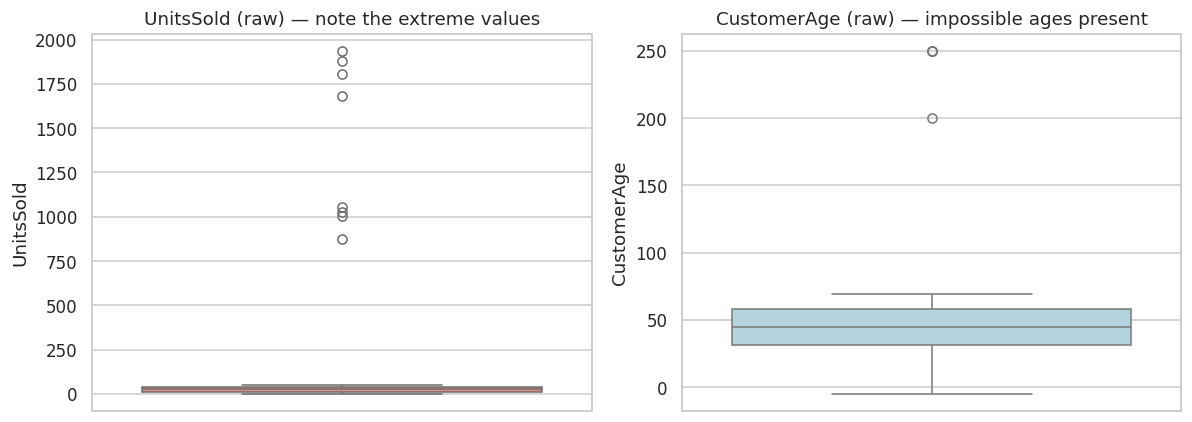

In [5]:
# A quick look at outliers before cleaning
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df["UnitsSold"], ax=axes[0], color="salmon")
axes[0].set_title("UnitsSold (raw) — note the extreme values")
sns.boxplot(y=df["CustomerAge"], ax=axes[1], color="lightblue")
axes[1].set_title("CustomerAge (raw) — impossible ages present")
plt.tight_layout()
plt.show()

## 2. Cleaning the Data

Steps: drop duplicates -> standardize text -> fill missing values ->
cap outliers with IQR -> recompute derived columns.

In [6]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 15 duplicate rows


In [7]:
df["Region"] = df["Region"].str.strip().str.title()
df["Category"] = df["Category"].str.strip().str.title()
df["Region"].unique()

<StringArray>
['South', nan, 'North', 'West', 'East']
Length: 5, dtype: str

In [8]:
df["Region"] = df["Region"].fillna("Unknown")
df["PaymentMethod"] = df["PaymentMethod"].fillna("Unknown")

for col in ["UnitsSold", "UnitPrice", "CustomerAge"]:
    df[col] = df[col].fillna(df[col].median())

df.isna().sum().sum()  # should be 0 now

np.int64(30)

In [9]:
def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return series.clip(lower=lower, upper=upper)

for col in ["UnitsSold", "CustomerAge"]:
    df[col] = cap_outliers_iqr(df[col])

df["Revenue"] = (df["UnitsSold"] * df["UnitPrice"]).round(2)
df["Month"] = df["OrderDate"].dt.month_name()
df["Quarter"] = df["OrderDate"].dt.to_period("Q").astype(str)
df.describe()

,OrderID,OrderDate,UnitsSold,UnitPrice,CustomerAge,Revenue
count,500.000000,500,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,2024-07-01 11:59:59.999999,26.280000,251.868060,44.880500,6626.885980
min,1001.000000,2024-01-01 00:00:00,1.000000,5.160000,-2.625000,27.520000
25%,1125.750000,2024-04-01 05:59:59.999999,15.000000,144.995000,33.750000,2182.155000
50%,1250.500000,2024-07-01 11:59:59.999999,26.000000,263.135000,45.000000,5245.210000
75%,1375.250000,2024-09-30 17:59:59.999999,37.000000,341.710000,58.000000,10233.715000
max,1500.000000,2024-12-31 00:00:00,70.000000,497.760000,94.375000,30769.200000
std,144.481833,NaN,14.503182,130.088882,15.535124,5352.539868


In [10]:
df.to_csv("../data/cleaned_sales_data.csv", index=False)
print("Cleaned dataset saved:", df.shape)

Cleaned dataset saved: (500, 11)


## 3. Exploratory Data Analysis & Visual Insights

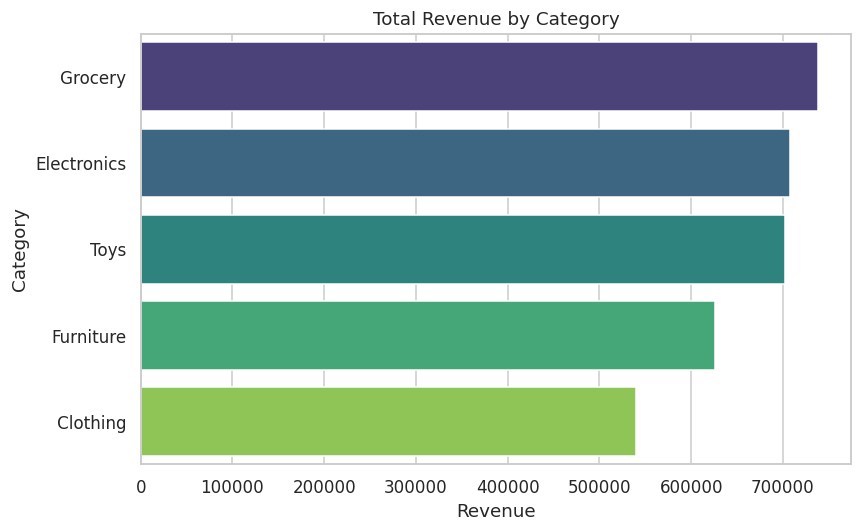

In [11]:
rev_by_cat = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=rev_by_cat.values, y=rev_by_cat.index, hue=rev_by_cat.index, palette="viridis", legend=False)
plt.title("Total Revenue by Category")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

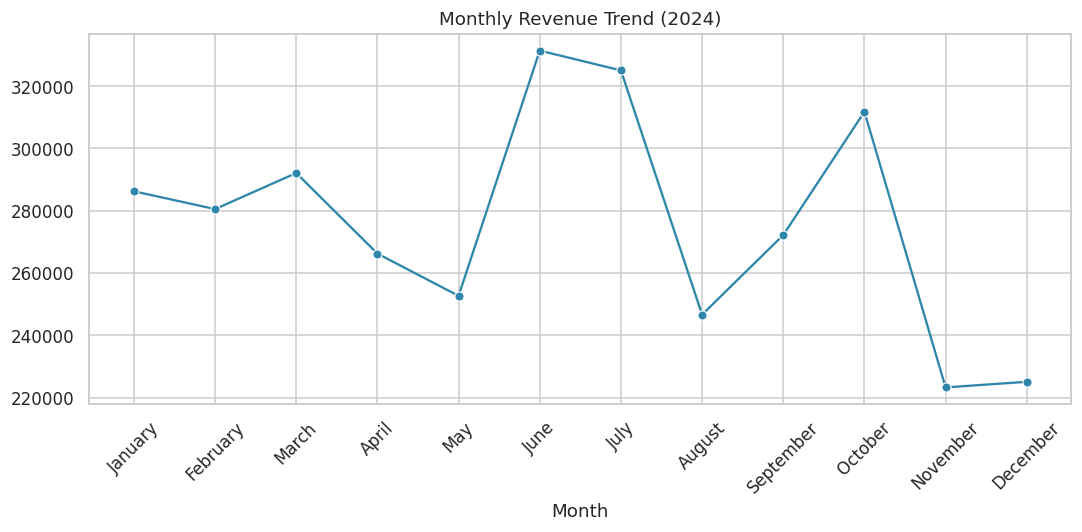

In [12]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
rev_by_month = df.groupby("Month")["Revenue"].sum().reindex(month_order)
plt.figure(figsize=(10, 5))
sns.lineplot(x=rev_by_month.index, y=rev_by_month.values, marker="o", color="#2E86AB")
plt.title("Monthly Revenue Trend (2024)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

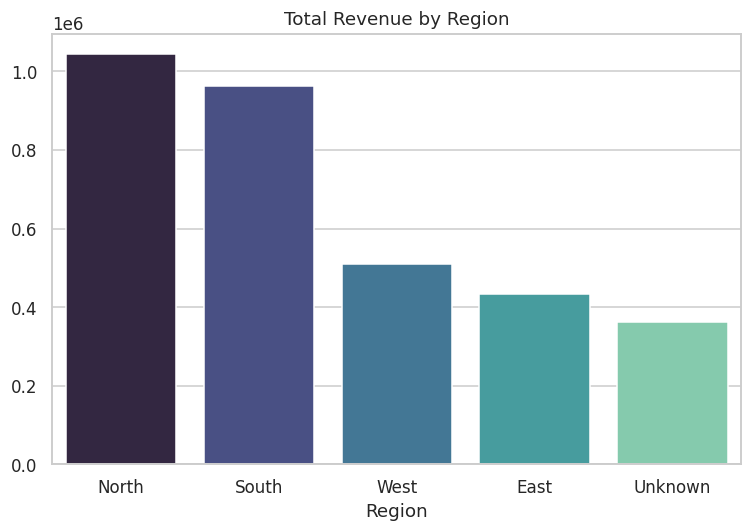

In [13]:
rev_by_region = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
sns.barplot(x=rev_by_region.index, y=rev_by_region.values, hue=rev_by_region.index, palette="mako", legend=False)
plt.title("Total Revenue by Region")
plt.tight_layout()
plt.show()

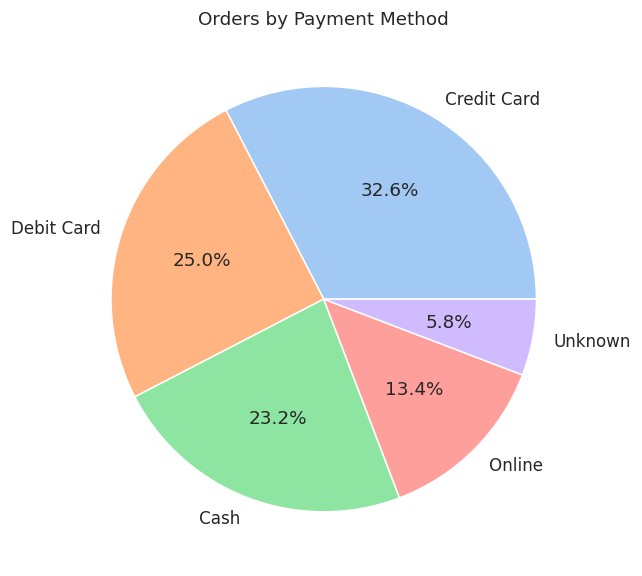

In [14]:
payment_counts = df["PaymentMethod"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Orders by Payment Method")
plt.tight_layout()
plt.show()

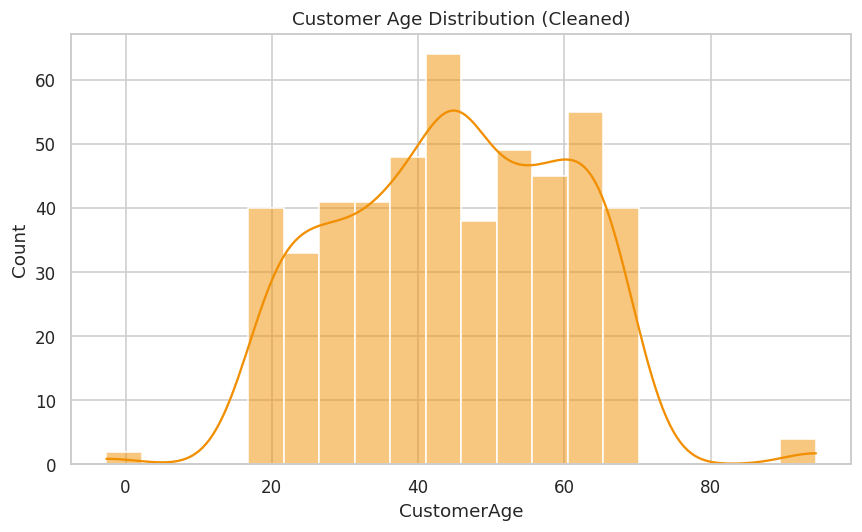

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["CustomerAge"], bins=20, kde=True, color="#F18F01")
plt.title("Customer Age Distribution (Cleaned)")
plt.tight_layout()
plt.show()

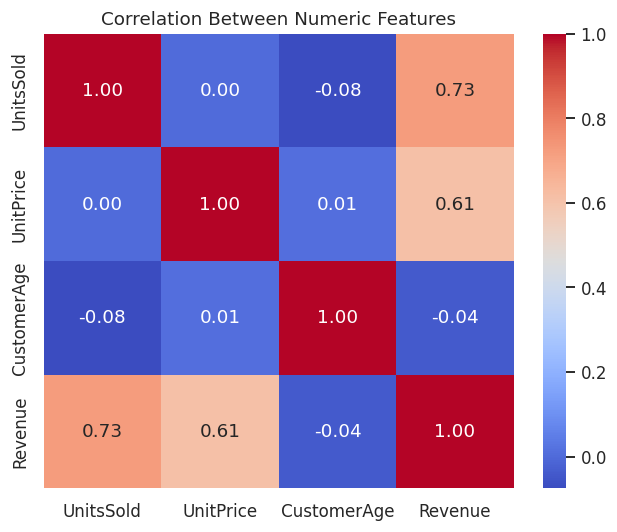

In [16]:
plt.figure(figsize=(6, 5))
numeric_cols = df[["UnitsSold", "UnitPrice", "CustomerAge", "Revenue"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

## 4. Key Findings

- **Grocery** is the top revenue-generating category.
- **June** was the strongest sales month in 2024.
- **North** region leads in total revenue.
- **Credit Card** is the most common payment method (~33% of orders).
- Cleaning removed 15 duplicate rows, filled ~150 missing values across 5 columns,
  and capped 14 outlier values using the IQR method — all without dropping any real
  observations, so no data was wasted.
